# Stability Pairwise ARI

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score
import sklearn.metrics
from tqdm import tqdm
import numpy as np
import pickle
from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt
import corc.our_datasets
import os

path = cache_path = '../../cache/'

In [3]:
def setup_plot_style():
    """Define common style elements for plots."""
    return {
        'colors': {
            'mnist': "#e41a1c", # red
            'densired': "#87CEEB", # light blue (earlier: cyan)
            'densired_soft_': "#377eb8", # blue
            'blobs1_': "#984ea3", # purple
            'blobs2_': "#4daf4a" # green
        },
        'fontsize': {
            'labels': 6,
            'ticks': 6,
            'legend': 6
        }
    }

def create_errorbar_plot(ax, data_dict, key2_labels, colors, jitter_range=(-0.1, 0.1)):
    """Create an errorbar plot for the given data."""
    # jitter = np.linspace(*jitter_range, len(key2_labels))
    for index, (key1, subdict) in enumerate(data_dict.items()):
        for i, key2 in enumerate(key2_labels):
            try: 
                vals = subdict[key2]
                mean_val = np.mean(vals)
                std_val = np.std(vals)
                label = key1[:-1] if key1.endswith('_') else key1
                translated_label = corc.our_datasets.dataset_displaynames.get(label, label)
                # if label == 'densired_soft':
                #     label = 'densired\nsoft'
                # print(jitter[i])
                ax.errorbar(
                    i +  index*0.15 - len(key2_labels) * 0.15 / 2,
                    # i + np.random.uniform(*jitter_range),
                    mean_val,
                    yerr=std_val,
                    fmt='o',
                    color=colors[key1],
                    label=label if i == 0 else "",
                    markersize=3
                )
            except:
                pass

def style_axis(ax, key2_labels, fontsize, ylabel=None):
    """Apply consistent styling to an axis."""
    ax.set_xticks(range(len(key2_labels)))
    ax.set_xticklabels(key2_labels)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=fontsize['labels'], labelpad=2)
    ax.tick_params(labelsize=fontsize['ticks'])
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def plot_comparison(ari_per_ds_bw, ari_overclust, figsize=(3.5, 1.8)):
    """Create a comparison plot with two subplots and outside legend."""
    style = setup_plot_style()
    key2_labels = list(next(iter(ari_per_ds_bw.values())).keys())
    
    # Create figure with gridspec
    fig = plt.figure(figsize=figsize)
    
    # Create gridspec with space for legend
    gs = fig.add_gridspec(2, 3, height_ratios=[1, 0.1], width_ratios=[1, 1, 0.3])
    
    # Create main subplot axes
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1], sharey=ax1)
    
    # Create errorbar plots
    create_errorbar_plot(ax1, ari_per_ds_bw, key2_labels, style['colors'])
    create_errorbar_plot(ax2, ari_overclust, key2_labels, style['colors'])
    
    # Style axes
    style_axis(ax1, key2_labels, style['fontsize'], ylabel="Pairwise ARI")
    style_axis(ax2, key2_labels, style['fontsize'])
    ax1.set_ylim(0, 1)
    
    # Add legend to the right of the plots
    handles, labels = ax2.get_legend_handles_labels()
    legend = fig.legend(
        handles, (corc.our_datasets.dataset_displaynames[label] for label in labels),
        frameon=False,
        fontsize=style['fontsize']['legend'],
        loc='center right',
        bbox_to_anchor=(0.87, 0.6),
        handletextpad=0.01,
        scatterpoints=1
    )
    
    # Add shared x-label
    # Adjust spacing
    # plt.tight_layout()
    plt.tight_layout(w_pad=1.5)  # Increase the width padding between subplots
    plt.subplots_adjust(right=0.85)
    fig.text(0.4, 0.18, 'Dataset Dimension', 
             ha='center', va='center', 
             fontsize=style['fontsize']['labels'])
    

    # Add labels A and B relative to the y-axis label
    ax1.annotate('A', xy=(0, 1), xycoords='axes fraction',
                 xytext=(-20, -10), textcoords='offset points',
                 ha='right', va='bottom', size=10, weight='bold')
    
    ax2.annotate('B', xy=(0, 1), xycoords='axes fraction',
                 xytext=(-18, -10), textcoords='offset points',
                 ha='right', va='bottom', size=10, weight='bold')
    return fig, (ax1, ax2)

## Stability

In [4]:
# ds_starts = ['mnist', 'densired', 'densired_soft_']
ds_starts = ['mnist', 'densired', 'densired_soft_', 'blobs1_', 'blobs2_']
ds_dims = [8, 16, 32, 64]
# ds_end = '_25.pkl'
# ds_end = '_35.pkl'
# gmm = '_gmm'
# gmm = ""

algorithm = "TMM-NEB"
# algorithm = "GMM-NEB"

In [13]:
ari_per_dataset_seeds = {}
for ds_name in tqdm(ds_starts):
    ari_per_dataset_seeds[ds_name] = {}
    for dim in ds_dims:
        ari_per_dataset_seeds[ds_name][dim] = []

        # Load dataset and models
        dataset = f"{ds_name}{dim}"
        X,y,tsne = corc.utils.load_dataset(dataset, cache_path=cache_path)
        tmm_models = corc.utils.load_algorithms(dataset,algorithm=algorithm, cache_path=cache_path)

        # evaluate models
        n_classes = len(np.unique(y))
        predictions = {tmm_model: tmm_model.predict_with_target(X, n_classes) for tmm_model in tmm_models}
        for model1, model2 in combinations(tmm_models, 2):
            ari_per_dataset_seeds[ds_name][dim].append(
                adjusted_rand_score(predictions[model1], predictions[model2])
            )

 80%|████████  | 4/5 [00:09<00:02,  2.33s/it]

6 clusters is not achievable.
Working with 3 clusters instead.
6 clusters is not achievable.
Working with 5 clusters instead.
6 clusters is not achievable.
Working with 4 clusters instead.
6 clusters is not achievable.
Working with 3 clusters instead.
6 clusters is not achievable.
Working with 5 clusters instead.
6 clusters is not achievable.
Working with 3 clusters instead.
6 clusters is not achievable.
Working with 3 clusters instead.
6 clusters is not achievable.
Working with 4 clusters instead.
6 clusters is not achievable.
Working with 3 clusters instead.


100%|██████████| 5/5 [00:11<00:00,  2.39s/it]

6 clusters is not achievable.
Working with 5 clusters instead.
6 clusters is not achievable.
Working with 2 clusters instead.
6 clusters is not achievable.
Working with 2 clusters instead.
6 clusters is not achievable.
Working with 3 clusters instead.
6 clusters is not achievable.
Working with 4 clusters instead.
6 clusters is not achievable.
Working with 3 clusters instead.
6 clusters is not achievable.
Working with 4 clusters instead.
6 clusters is not achievable.
Working with 1 clusters instead.
6 clusters is not achievable.
Working with 4 clusters instead.


In [14]:
gmm=""

ari_per_dataset_overclustering = {}
for ds_name in tqdm(ds_starts):
    ari_per_dataset_overclustering[ds_name] = {}
    for dim in ds_dims:
        # if ds_name == 'blobs1_' and dim == 64:
        #     continue
        ari_per_dataset_overclustering[ds_name][dim] = []
        
        filepath = f'{path}stability/overclustering_{ds_name}{dim}{gmm}.pkl'
        if os.path.exists(filepath):
            with open(filepath, 'rb') as f:
                tmm_models = pickle.load(f)
        else:
            continue
        
        # skip first two models as they do not use proper "joining" of clusters
        tmm_models = tmm_models[2:10]
            
        X, y, tsne = corc.utils.load_dataset(f'{ds_name}{dim}',cache_path=cache_path)
        n_classes = len(np.unique(y))
        predictions = {s: s.predict_with_target(X, n_classes) for s in tmm_models}

        # pairwise ari
        for model1, model2 in combinations(tmm_models, 2):
            ari_per_dataset_overclustering[ds_name][dim].append(
                adjusted_rand_score(predictions[model1], predictions[model2])
            )

100%|██████████| 5/5 [00:26<00:00,  5.25s/it]


In [15]:
keys = ['mnist', 'densired', 'densired_soft_']
main_ari_per_dataset_seeds = {key: ari_per_dataset_seeds[key] for key in keys }
# main_ari_per_dataset_overclustering = dict()
main_ari_per_dataset_overclustering = {key: ari_per_dataset_overclustering[key] for key in keys}

/user/ritzert/u14643/micromamba/envs/tneb/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/user/ritzert/u14643/micromamba/envs/tneb/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/user/ritzert/u14643/micromamba/envs/tneb/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/user/ritzert/u14643/micromamba/envs/tneb/lib/python3.11/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/user/ritzert/u14643/micromamba/envs/tneb/lib/python3.11/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


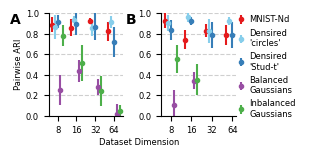

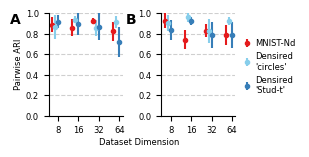

In [ ]:
# fig, axes = plot_comparison(ari_per_dataset_seeds, ari_per_dataset_overclustering)
# plt.savefig(f"../../figures/stability_errorbars{gmm}_full.pdf",
#             bbox_inches='tight', pad_inches=0)

fig, axes = plot_comparison(main_ari_per_dataset_seeds, main_ari_per_dataset_overclustering)
plt.savefig(f"../../figures/stability_errorbars{gmm}2.pdf",
            bbox_inches='tight', pad_inches=0)